In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Set visual style
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

In [4]:
# Adjust the path based on where you run the notebook
data_path = "C:/Users/artem/Downloads/MLOps/Used Car Project/data/raw/car_prices_3.csv"
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (517050, 16)


,COMPANY,MODEL,TYPE,SIZE,transmission,state,condition,odometer,color,interior_color,seller,mmr,sellingprice,sale_day,sale_month,sale_year
0,Kia,Sorento,LX,SUV,automatic,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue,Dec,2014.0
1,Kia,Sorento,LX,SUV,automatic,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue,Dec,2014.0
2,BMW,3 Series,328i SULEV,Sedan,automatic,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu,Jan,2015.0
3,Volvo,S60,T5,Sedan,automatic,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu,Jan,2015.0
4,BMW,6 Series Gran Coupe,650i,Sedan,automatic,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu,Dec,2014.0


In [5]:
# Check data types and non-null counts
df.info()

# Calculate the percentage of missing values per column
missing_pct = df.isnull().mean() * 100
print("\nMissing Values Percentage:")
print(missing_pct[missing_pct > 0].sort_values(ascending=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517050 entries, 0 to 517049
Data columns (total 16 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   COMPANY         507329 non-null  object 
 1   MODEL           507248 non-null  object 
 2   TYPE            507020 non-null  object 
 3   SIZE            504756 non-null  object 
 4   transmission    457268 non-null  object 
 5   state           517050 non-null  object 
 6   condition       510556 non-null  float64
 7   odometer        516989 non-null  float64
 8   color           516301 non-null  object 
 9   interior_color  516301 non-null  object 
 10  seller          517050 non-null  object 
 11  mmr             517039 non-null  float64
 12  sellingprice    517039 non-null  float64
 13  sale_day        517039 non-null  object 
 14  sale_month      517039 non-null  object 
 15  sale_year       517039 non-null  float64
dtypes: float64(5), object(11)
memory usage: 63.1+ MB

Missin

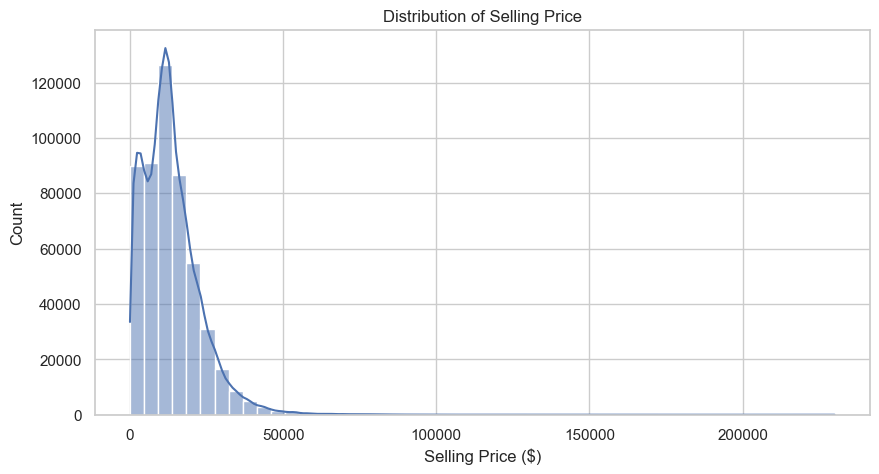

count    517039.000000
mean      13510.101623
std        9651.853771
min           1.000000
25%        6800.000000
50%       12000.000000
75%       18000.000000
max      230000.000000
Name: sellingprice, dtype: float64

In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(df['sellingprice'], bins=50, kde=True)
plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price ($)")
plt.show()

# Look for obvious outliers
df['sellingprice'].describe()

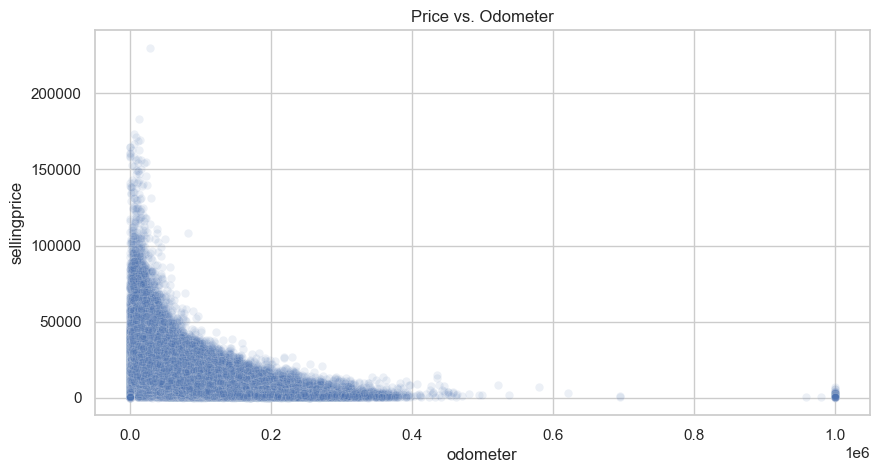

count    516989.000000
mean      68720.500152
std       53269.530565
min           1.000000
25%       28856.000000
50%       53051.000000
75%       99487.000000
max      999999.000000
Name: odometer, dtype: float64


In [7]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x='odometer', y='sellingprice', data=df, alpha=0.1)
plt.title("Price vs. Odometer")
plt.show()

# Check for strange mileage values
print(df['odometer'].describe())

COMPANY: 94 unique values
TYPE: 1920 unique values
SIZE: 85 unique values
transmission: 2 unique values
condition: 41 unique values


<Axes: title={'center': 'Top 10 Car Companies'}, xlabel='COMPANY'>

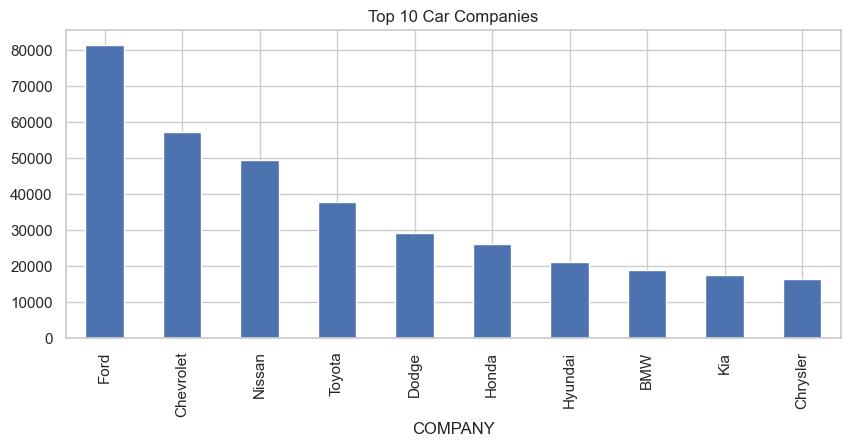

In [8]:
categorical_cols = ['COMPANY', 'TYPE', 'SIZE', 'transmission', 'condition']

for col in categorical_cols:
    unique_count = df[col].nunique()
    print(f"{col}: {unique_count} unique values")
    
# Let's look at the top 10 companies by volume
df['COMPANY'].value_counts().head(10).plot(kind='bar', figsize=(10,4), title='Top 10 Car Companies')

In [15]:
# Create a fresh copy to experiment on
df_clean = df.copy()
print(f"Starting shape: {df_clean.shape}")

Starting shape: (517050, 16)


In [16]:
# Drop rows where we don't know the price (target)
df_clean = df_clean.dropna(subset=['sellingprice', 'mmr'])

# Filter extreme prices (keeps linear regression stable)
df_clean = df_clean[(df_clean['sellingprice'] >= 500) & (df_clean['sellingprice'] <= 100000)]

# Filter impossible/extreme odometer readings
df_clean = df_clean[df_clean['odometer'] <= 300000]

print(f"Shape after filtering targets & outliers: {df_clean.shape}")

Shape after filtering targets & outliers: (511541, 16)


In [17]:
# Drop rows with missing critical core features
df_clean = df_clean.dropna(subset=['COMPANY', 'MODEL', 'TYPE', 'SIZE'])

print(f"Shape after dropping small NaNs: {df_clean.shape}")

Shape after dropping small NaNs: (499755, 16)


In [18]:
# 1. Map months to numbers safely
month_map = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
             'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}
df_clean['sale_month'] = df_clean['sale_month'].astype(str).str[:3].map(month_map)

# 2. Dummify the month (Convert to string first so Pandas knows it's a category)
df_clean['sale_month'] = df_clean['sale_month'].astype(str)
df_clean = pd.get_dummies(df_clean, columns=['sale_month'], drop_first=True)

# 3. Drop the noise
df_clean = df_clean.drop(columns=['sale_day'])

print(f"Dataset shape ready for modeling: {df_clean.shape}")

Dataset shape ready for modeling: (499755, 21)


In [19]:
# Find the top 20 companies by volume
top_companies = df_clean['COMPANY'].value_counts().nlargest(20).index

# Replace any company NOT in the top 20 with 'Other'
df_clean['COMPANY'] = df_clean['COMPANY'].where(df_clean['COMPANY'].isin(top_companies), 'Other')

print("New Company Value Counts:")
print(df_clean['COMPANY'].value_counts())

New Company Value Counts:
COMPANY
Ford             80657
Chevrolet        56725
Nissan           49287
Other            46384
Toyota           37476
Dodge            28899
Honda            25741
Hyundai          20803
BMW              18637
Kia              17292
Chrysler         16247
Mercedes-Benz    14637
Jeep             14580
Infiniti         14134
Lexus            11179
Volkswagen       10946
GMC              10126
Mazda             7922
Cadillac          7082
Acura             5616
Audi              5385
Name: count, dtype: int64


In [20]:
# Check remaining missing values
missing = df_clean.isnull().sum()
print("Remaining missing values (to be handled by scikit-learn imputer later):")
print(missing[missing > 0])

# For this baseline notebook experiment, let's drop TYPE and MODEL 
# to avoid blowing up our memory when we one-hot encode.
df_clean = df_clean.drop(columns=['TYPE', 'MODEL'])

Remaining missing values (to be handled by scikit-learn imputer later):
transmission      57259
condition          5925
color               701
interior_color      701
dtype: int64


In [21]:
# 1. Create a fresh working copy
df_clean = df.copy()
print(f"Original shape: {df_clean.shape}")

# 2. Clean Target Variables & Extreme Outliers
# Drop missing targets
df_clean = df_clean.dropna(subset=['sellingprice', 'mmr'])

# Keep prices between $500 and $100k to stabilize linear regression
df_clean = df_clean[(df_clean['sellingprice'] >= 500) & (df_clean['sellingprice'] <= 100000)]

# Filter out extreme/impossible odometer readings
df_clean = df_clean[df_clean['odometer'] <= 300000]

# 3. Handle Small Missing Values (< 3% data loss)
df_clean = df_clean.dropna(subset=['COMPANY', 'MODEL', 'TYPE', 'SIZE'])

# 4. Feature Engineering: Dates
# Map month strings to safe numerical categories
month_map = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
             'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}
df_clean['sale_month'] = df_clean['sale_month'].astype(str).str[:3].map(month_map)

# Dummify the month (Convert to string first so Pandas knows it's a category)
df_clean['sale_month'] = df_clean['sale_month'].astype(str)
df_clean = pd.get_dummies(df_clean, columns=['sale_month'], drop_first=True)

# Drop the noise
df_clean = df_clean.drop(columns=['sale_day'])

# 5. Handle High Cardinality (The Companies)
# Keep the top 20 companies by volume
top_companies = df_clean['COMPANY'].value_counts().nlargest(20).index

# Replace any company NOT in the top 20 with 'Other'
df_clean['COMPANY'] = df_clean['COMPANY'].where(df_clean['COMPANY'].isin(top_companies), 'Other')

# 6. Drop specific high-cardinality columns for the baseline to prevent memory crashes
df_clean = df_clean.drop(columns=['TYPE', 'MODEL'])

print(f"Final dataset shape ready for scikit-learn: {df_clean.shape}")

Original shape: (517050, 16)
Final dataset shape ready for scikit-learn: (499755, 19)


In [22]:
# Check remaining missing values
missing = df_clean.isnull().sum()
print("Remaining missing values (to be handled by scikit-learn imputer later):")
print(missing[missing > 0])

# For this baseline notebook experiment, let's drop TYPE and MODEL 
# to avoid blowing up our memory when we one-hot encode.
df_clean = df_clean.drop(columns=['TYPE', 'MODEL'])

Remaining missing values (to be handled by scikit-learn imputer later):
transmission      57259
condition          5925
color               701
interior_color      701
dtype: int64


KeyError: "['TYPE', 'MODEL'] not found in axis"

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 1. Split into Features (X) and Target (y)
X = df_clean.drop(columns=['sellingprice', 'mmr'])
y = df_clean['sellingprice']

# 2. Define which columns get which treatment
numeric_features = ['odometer', 'condition', 'months_elapsed']
categorical_features = ['COMPANY', 'SIZE', 'transmission', 'state', 'color', 'interior_color', 'seller']

# 3. Build the Numeric Pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 4. Build the Categorical Pipeline
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    # handle_unknown='ignore' prevents errors if a new color appears in the future
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) 
])

# 5. Combine them into the final Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' # Keeps any columns we already dummified (like sale_month)
)

# 6. Apply the transformations!
X_transformed = preprocessor.fit_transform(X)

print(f"Original X shape: {X.shape}")
print(f"Transformed X shape: {X_transformed.shape}")
print("No more missing values! The data is officially ready for the Baseline Model.")

ValueError: A given column is not a column of the dataframe

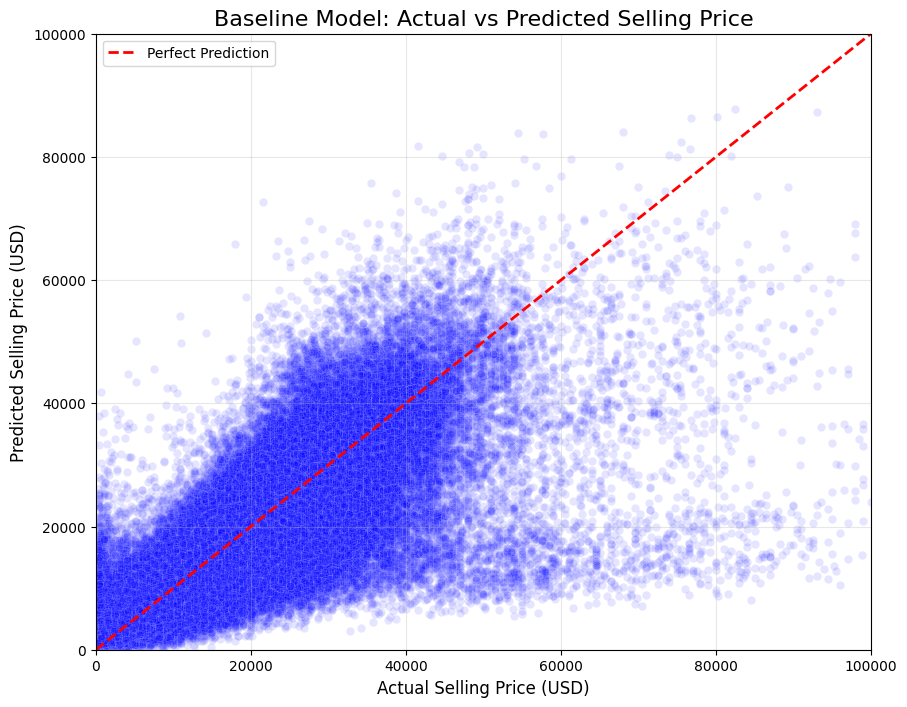

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# 1. Load Data and Model
# (Assuming your notebook is inside a 'notebooks/' folder at the root level)
df = pd.read_parquet('C:/Users/artem/Downloads/MLOps/Used Car Project/data/processed/num_dataset.parquet')
model = joblib.load('C:/Users/artem/Downloads/MLOps/Used Car Project/models/baseline.pkl')

# 2. Separate Features (X) and Target (y)
X = df.drop(columns=['sellingprice'])
y_true = df['sellingprice']

# 3. Generate Predictions
y_pred = np.expm1(model.predict(X))

# ==========================================
# EXPONENTIAL TRANSFORMATION (Read Note)
# ==========================================
# If you log-transformed your target during training (e.g., np.log1p), 
# uncomment the line below to convert predictions back to dollars (np.expm1).
# Since our current pipeline uses raw dollars, leave this commented out!

# y_pred = np.expm1(y_pred)
# ==========================================

# 4. Plot Actual vs. Predicted using Seaborn
plt.figure(figsize=(10, 8))

# Use a scatter plot with high transparency (alpha) to handle dense data points
sns.scatterplot(x=y_true, y=y_pred, alpha=0.1, color="blue")

# Add a red diagonal line showing where "Perfect Predictions" would fall
max_val = min(y_true.max(), 100000) # Cap the chart at 100k for readability
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

# Formatting
plt.xlim(0, max_val)
plt.ylim(0, max_val)
plt.title('Baseline Model: Actual vs Predicted Selling Price', fontsize=16)
plt.xlabel('Actual Selling Price (USD)', fontsize=12)
plt.ylabel('Predicted Selling Price (USD)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

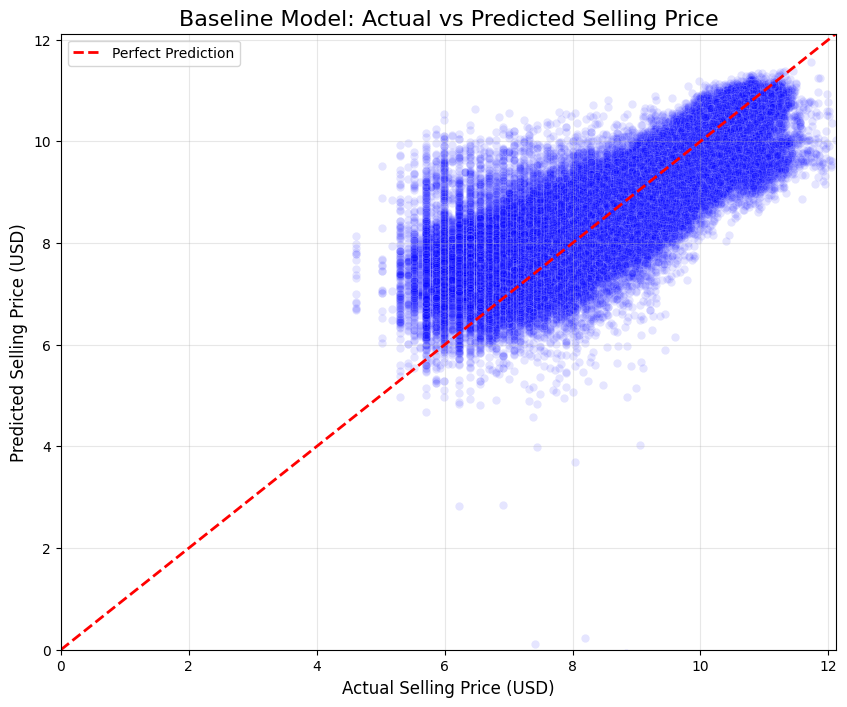

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# 1. Load Data and Model
# (Assuming your notebook is inside a 'notebooks/' folder at the root level)
df = pd.read_parquet('C:/Users/artem/Downloads/MLOps/Used Car Project/data/processed/num_dataset.parquet')
model = joblib.load('C:/Users/artem/Downloads/MLOps/Used Car Project/models/baseline.pkl')
expected_columns = pd.read_pickle('C:/Users/artem/Downloads/MLOps/Used Car Project/models/expected_columns.pkl')

X = X.reindex(columns=expected_columns, fill_value=0)
# 2. Separate Features (X) and Target (y)
# X = df.drop(columns=['sellingprice'])
y_true = np.log1p(df['sellingprice'])
# 3. Generate Predictions
y_pred = (model.predict(X))

# ==========================================
# EXPONENTIAL TRANSFORMATION (Read Note)
# ==========================================
# If you log-transformed your target during training (e.g., np.log1p), 
# uncomment the line below to convert predictions back to dollars (np.expm1).
# Since our current pipeline uses raw dollars, leave this commented out!

# y_pred = np.expm1(y_pred)
# ==========================================

# 4. Plot Actual vs. Predicted using Seaborn
plt.figure(figsize=(10, 8))

# Use a scatter plot with high transparency (alpha) to handle dense data points
sns.scatterplot(x=y_true, y=y_pred, alpha=0.1, color="blue")

# Add a red diagonal line showing where "Perfect Predictions" would fall
max_val = min(y_true.max(), 100000) # Cap the chart at 100k for readability
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

# Formatting
plt.xlim(0, max_val)
plt.ylim(0, max_val)
plt.title('Baseline Model: Actual vs Predicted Selling Price', fontsize=16)
plt.xlabel('Actual Selling Price (USD)', fontsize=12)
plt.ylabel('Predicted Selling Price (USD)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

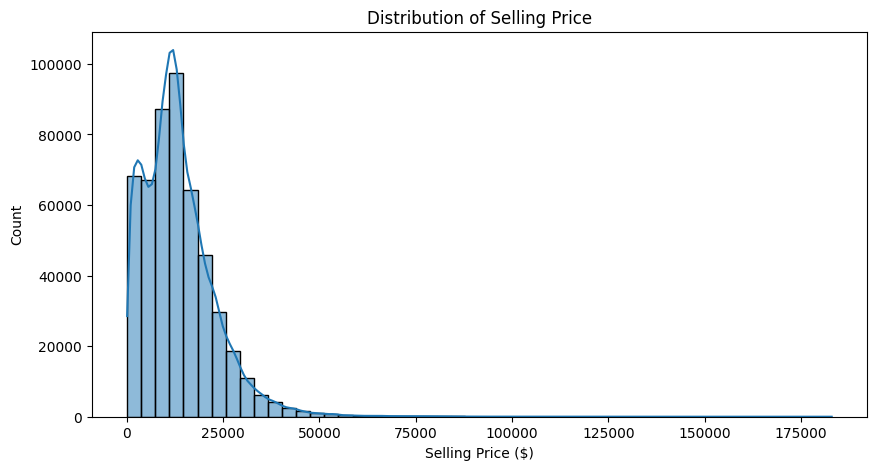

count    507258.000000
mean      13597.205830
std        9625.141421
min         100.000000
25%        7000.000000
50%       12100.000000
75%       18100.000000
max      183000.000000
Name: sellingprice, dtype: float64

In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(df['sellingprice'], bins=50, kde=True)
plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price ($)")
plt.show()

# Look for obvious outliers
df['sellingprice'].describe()

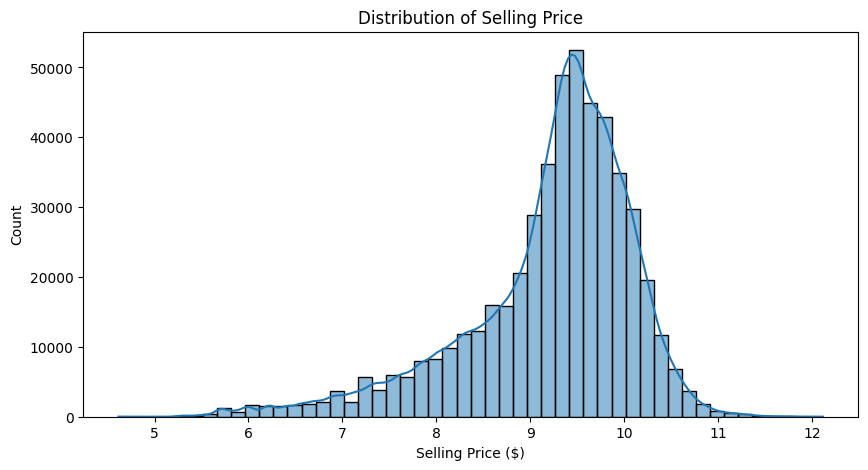

count    507258.000000
mean          9.216609
std           0.900574
min           4.615121
25%           8.853808
50%           9.401043
75%           9.803722
max          12.117247
Name: sellingprice, dtype: float64

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(df['sellingprice']), bins=50, kde=True)
plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price ($)")
plt.show()

# Look for obvious outliers
np.log1p(df['sellingprice']).describe()